Duplicates to be removed: 10066
Total BENIGN URLs: 428080
Total MALICIOUS URLs: 213045
Removed 215035 data points of class *benign* to balance the dataset.

Optimal k: 8

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.86      0.81     42558
           1       0.84      0.74      0.79     42660

    accuracy                           0.80     85218
   macro avg       0.81      0.80      0.80     85218
weighted avg       0.81      0.80      0.80     85218

Confusion Matrix:
[[42.93  7.01]
 [12.91 37.15]]
[[36585  5973]
 [11000 31660]]

NOTE: red indicates a malignant prediction, blue indicates a benign prediction


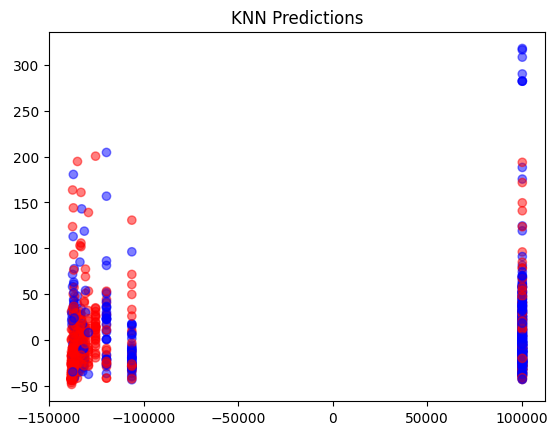


Accuracy: 0.8008284634701589


In [2]:
import numpy as np
import pandas as pd
import process_dataset as pds
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

#Read list of urls and their labels from source file
#Separate the urls and labels using process_dataset.py
data = pd.read_csv('malicious_phish.csv')
urls, labels = pds.process_dataset(data)

#Split the dataset into testing and training sets
X_train, X_test, y_train, y_test = train_test_split(urls, labels, test_size=0.2, shuffle=True)

#Instantiate variables in order to find an optimal k value for knn training
#In this case, we will check values 1-30 for k
k = 1
potential_k = range(1, 31)
curr_best = 0

#Find the optimal number of neighbors in the given range/
for i in potential_k:
    knn = KNeighborsClassifier(n_neighbors=i)

    #5-fold cross-validation with each k, checking for accuracy
    scores = cross_val_score(knn, X_train, y_train, scoring='accuracy')

    #Record the k value that provides best average accuracy
    if np.mean(scores) > curr_best:
        curr_best = np.mean(scores)
        k = i

#Instantiate and train the KNN classifier with the optimal k, p=1 ensure distance metric calculated using Manhattan Distance
knn_classifier = KNeighborsClassifier(n_neighbors=k, p=1, weights='distance')
knn_classifier.fit(X_train, y_train)

#Predict labels for test data. This will be used to calculate the overall accuracy, precision, and recall of the KNN
predictions = knn_classifier.predict(X_test)

print()
print(f'Optimal k: {k}')
print()
print('Classification Report:')
print(classification_report(y_test, predictions))

#Print out the confusion matrix for the model
cm = confusion_matrix(y_test, predictions)
print('Confusion Matrix:')
print(np.round(cm * 100 / np.sum(cm), 2))
print(cm)
print()

#When plotting a graph to show the knn predictions, only a small sample of X_test will be used for the sake clarity
sample_points = X_test.sample(n=1000)
sample_predictions = knn_classifier.predict(sample_points)

#print knn graph
print('NOTE: red indicates a malignant prediction, blue indicates a benign prediction')
prediction_colors = np.where(sample_predictions == 1, 'r', 'b')
plt.scatter(sample_points[0], sample_points[1], c=prediction_colors, alpha=0.5)
plt.title('KNN Predictions')
plt.show()
print()

#Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy}')
